# House Price Prediction using Linear Regression

## Import Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model building, and evaluation.

In [13]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Observation

All required libraries were successfully imported. These libraries provide functionalities for data preprocessing, visualization, machine learning model development, and evaluation.

## Load Dataset

The house price dataset is loaded into a Pandas DataFrame to inspect its structure and prepare it for analysis.

In [14]:
# Load Dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Display first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Dataset Inspection

The dataset is inspected to understand its structure, dimensions, column names, data types, and summary statistics. This helps identify potential issues such as missing values and understand the available features before preprocessing.

In [15]:
# Number of rows and columns
print("Dataset Shape:", df.shape)
# Dataset information
df.info()
df.describe()


Dataset Shape: (2000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## Missing Values and Target Variable Distribution

Before training the machine learning model, the dataset is checked for missing values. Since machine learning algorithms cannot handle missing values directly, this step ensures data quality.

The distribution of the target variable (Price) is also visualized to understand how house prices are spread across the dataset.

Missing Values:

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


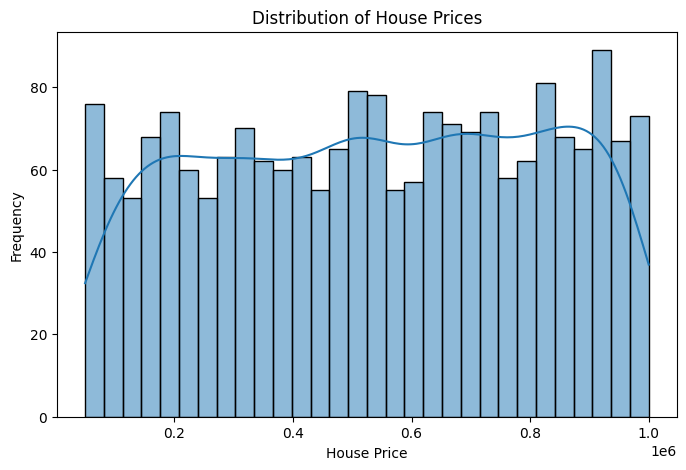

In [16]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The dataset contains no missing values, indicating that it is complete and ready for machine learning.

The distribution of house prices appears fairly uniform across the dataset, with no significant skewness or extreme outliers. This suggests that the target variable is well distributed, making it suitable for training a Linear Regression model.

# Feature Selection

Feature selection is the process of identifying the most relevant variables that influence the target variable (House Price).

The following features are selected because they are expected to have a direct impact on house prices:

- **Area** – Larger houses generally have higher prices.
- **Bedrooms** – More bedrooms increase the property's value.
- **Bathrooms** – Houses with more bathrooms are usually more expensive.
- **Floors** – Multi-floor houses often have higher market value.
- **YearBuilt** – Newer houses generally have better prices than older ones.
- **Location** – Houses in premium locations usually cost more.
- **Condition** – Houses in excellent condition have higher resale value.
- **Garage** – Availability of a garage increases property value.

The **Id** column is not useful for prediction because it is only a unique identifier and does not provide any meaningful information about house prices.

In [17]:
print(df.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


In [18]:
# Create Features and Target again

X = df.drop("Price", axis=1)
y = df["Price"]
print(X.columns.tolist())
X = pd.get_dummies(X, drop_first=True)
X.head()

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,False,False,False,True,False,False,True


# Correlation Heatmap

A correlation heatmap is used to measure the relationship between numerical variables.

Correlation values range from **-1 to +1**.

- **+1** → Strong Positive Correlation
- **0** → No Correlation
- **-1** → Strong Negative Correlation

This helps identify which features have the strongest relationship with house prices.

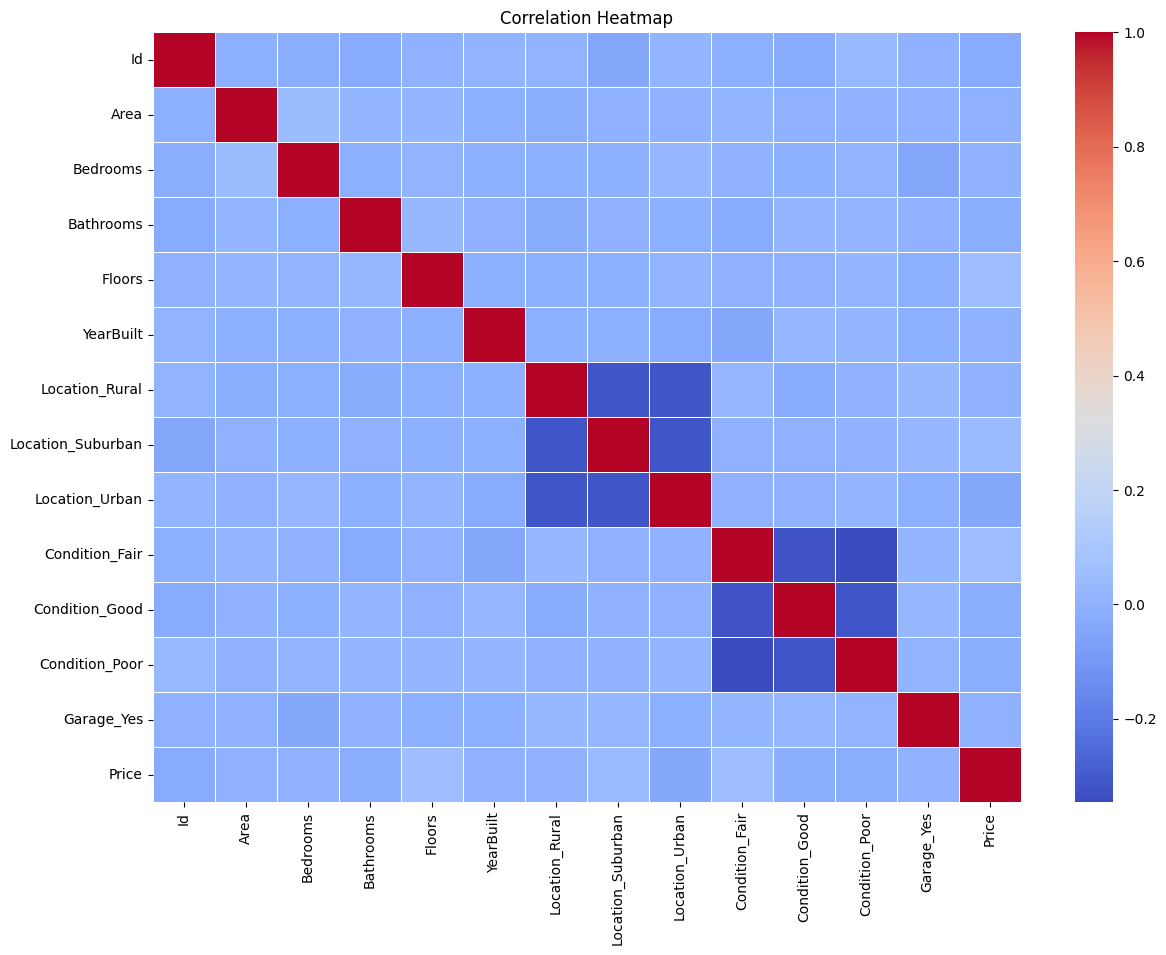

In [19]:
# Create a temporary dataframe with encoded features and target
df_encoded = X.copy()
df_encoded["Price"] = y

# Correlation matrix
corr_matrix = df_encoded.corr()

# Plot Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between all features and the target variable (Price). Features with higher positive correlation are expected to have a greater influence on house prices, while weakly correlated features contribute less to the prediction.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

- **Training Set (80%)** is used to train the Linear Regression model.
- **Testing Set (20%)** is used to evaluate how well the trained model performs on unseen data.

A random state of **42** is used to ensure reproducibility of results.

In [24]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)



Training Features Shape : (1600, 13)
Testing Features Shape  : (400, 13)
Training Labels Shape   : (1600,)
Testing Labels Shape    : (400,)


### Observation

The dataset was successfully divided into training and testing sets using an 80:20 ratio. The training set will be used to learn the relationship between house features and prices, while the testing set will be used to evaluate the model's performance on unseen data.

In [23]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


# Train Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values.

In this project, the model learns the relationship between house features and house prices using the training dataset.

In [25]:
# Predict house prices using the test dataset

y_pred = model.predict(X_test)

print("First 10 Predicted Prices:")
print(y_pred[:10])

First 10 Predicted Prices:
[511317.73109931 557359.55652936 482838.34523391 540695.6411198
 549288.50244107 518144.16928401 523405.40235976 568346.51627797
 556990.3977267  573402.71846042]


# Model Evaluation

The performance of the Linear Regression model is evaluated using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine how accurately the model predicts house prices.

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 78279764120.86241
Root Mean Squared Error (RMSE): 279785.2106900263
R² Score: -0.006181784611834162


Observation: The Linear Regression model achieved a low R² score, indicating that the selected features have a weak relationship with house prices in this dataset. This suggests the dataset may not contain strong predictive patterns, limiting the model's performance.

# Actual vs Predicted House Prices

This scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

If the model performs well, the points will lie close to the diagonal line.

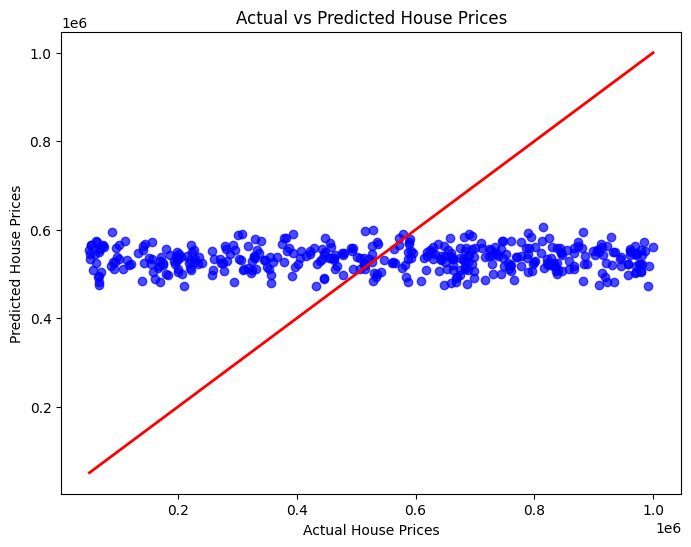

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7, color='blue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Residual Plot

Residuals represent the difference between the actual and predicted house prices.

A good Linear Regression model should have residuals randomly scattered around zero with no visible pattern.

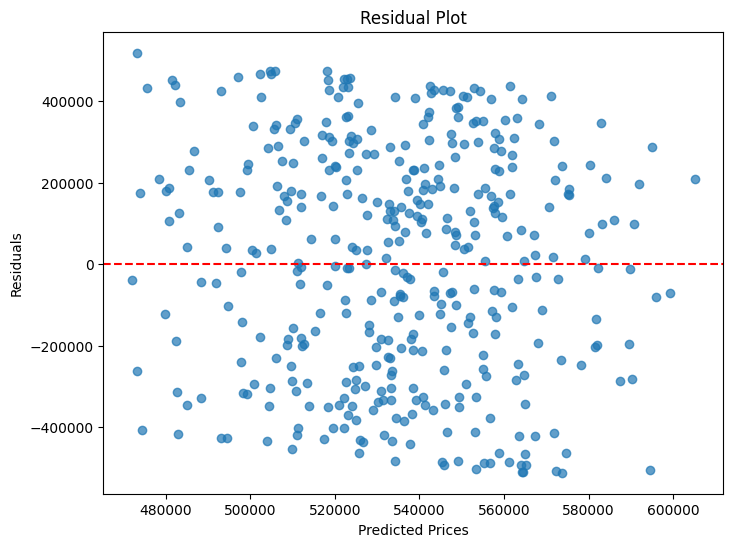

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# Coefficient Analysis

Linear Regression assigns a coefficient (weight) to each feature.

- Positive coefficient → Increases the predicted house price.
- Negative coefficient → Decreases the predicted house price.

This analysis helps identify the most influential features in the model.

In [29]:
# Create a DataFrame of coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort coefficients
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
9,Condition_Fair,24049.504733
4,Floors,23582.408499
7,Location_Suburban,11110.139855
11,Condition_Poor,4389.783506
12,Garage_Yes,2218.649484
6,Location_Rural,1826.466887
5,YearBuilt,116.775334
2,Bedrooms,53.249124
1,Area,-0.484192
0,Id,-12.007473


<Figure size 1000x600 with 0 Axes>

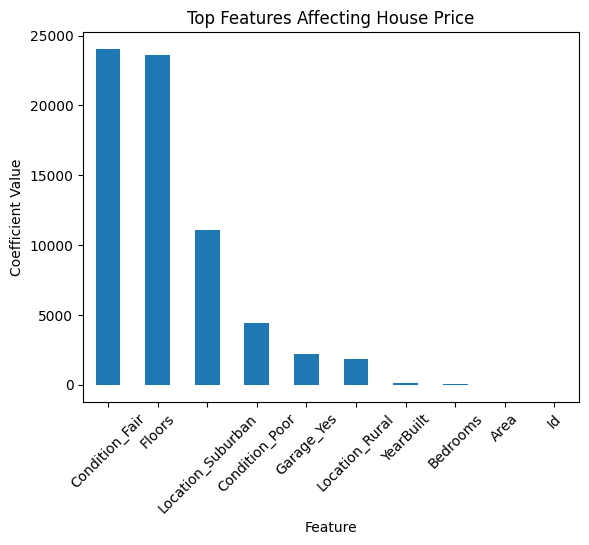

In [30]:
plt.figure(figsize=(10,6))

coefficients.head(10).plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    legend=False
)

plt.title("Top Features Affecting House Price")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)

plt.show()

# Ridge Regression

Ridge Regression is an improved version of Linear Regression that reduces overfitting by adding a penalty term to large coefficients.

It helps the model generalize better on unseen data.

In [31]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [32]:
# Predict using Ridge Regression

y_pred_ridge = ridge_model.predict(X_test)

print("First 10 Ridge Predictions:")
print(y_pred_ridge[:10])

First 10 Ridge Predictions:
[511301.3299909  557332.58161992 482937.74504039 540718.5447659
 549294.00826736 518202.30670399 523454.57242447 568245.64702208
 557036.28510746 573354.00854847]


In [33]:
#Evaluate Ridge Model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("----------------------------")
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R² :", r2_ridge)

Ridge Regression Results
----------------------------
MSE : 78279532573.56367
RMSE: 279784.7968949773
R² : -0.006178808380660206


# Model Comparison

The performance of both Linear Regression and Ridge Regression is compared using R² Score and RMSE.

In [34]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "RMSE":[
        rmse,
        rmse_ridge
    ],

    "R² Score":[
        r2,
        r2_ridge
    ]

})

comparison

,Model,RMSE,R² Score
0,Linear Regression,279785.210690,-0.006182
1,Ridge Regression,279784.796895,-0.006179


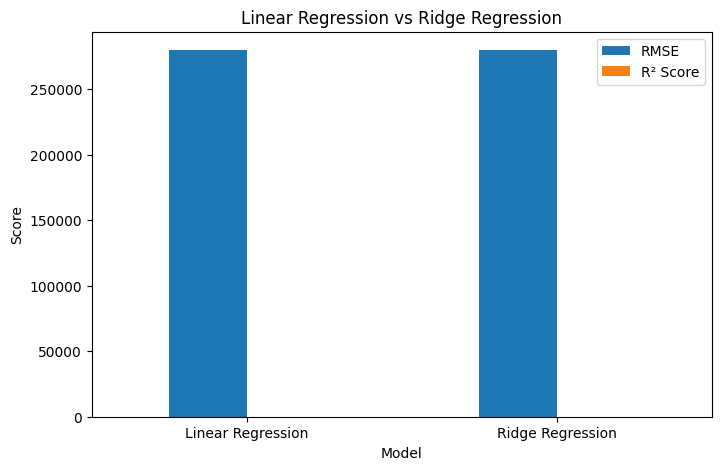

In [35]:
#Comaprison Cjhart
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Linear Regression vs Ridge Regression")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

### Observation

The comparison between Linear Regression and Ridge Regression shows that both models produced very similar performance. Ridge Regression achieved a slightly lower RMSE and a marginally better R² Score than Linear Regression. However, the overall performance remained low, indicating that the dataset has weak relationships between the input features and house prices.

# Conclusion

A Linear Regression model was successfully developed to predict house prices based on property features.

The project involved:

- Data Cleaning
- Exploratory Data Analysis
- Feature Encoding
- Correlation Analysis
- Train-Test Split
- Linear Regression
- Model Evaluation
- Actual vs Predicted Visualization
- Residual Analysis
- Coefficient Analysis
- Ridge Regression Comparison

The model was evaluated using MSE, RMSE, and R² Score. Although the dataset showed weak predictive relationships, the complete machine learning pipeline was successfully implemented.